Upload combined receipt image:


Saving input_image.jpeg to input_image (2).jpeg
Saved Slip 1: 397x543
Saved Slip 2: 397x883
Saved Slip 3: 284x598
Saved Slip 4: 262x559
Saved Slip 5: 354x644

Total slips saved: 5

Final Preview:


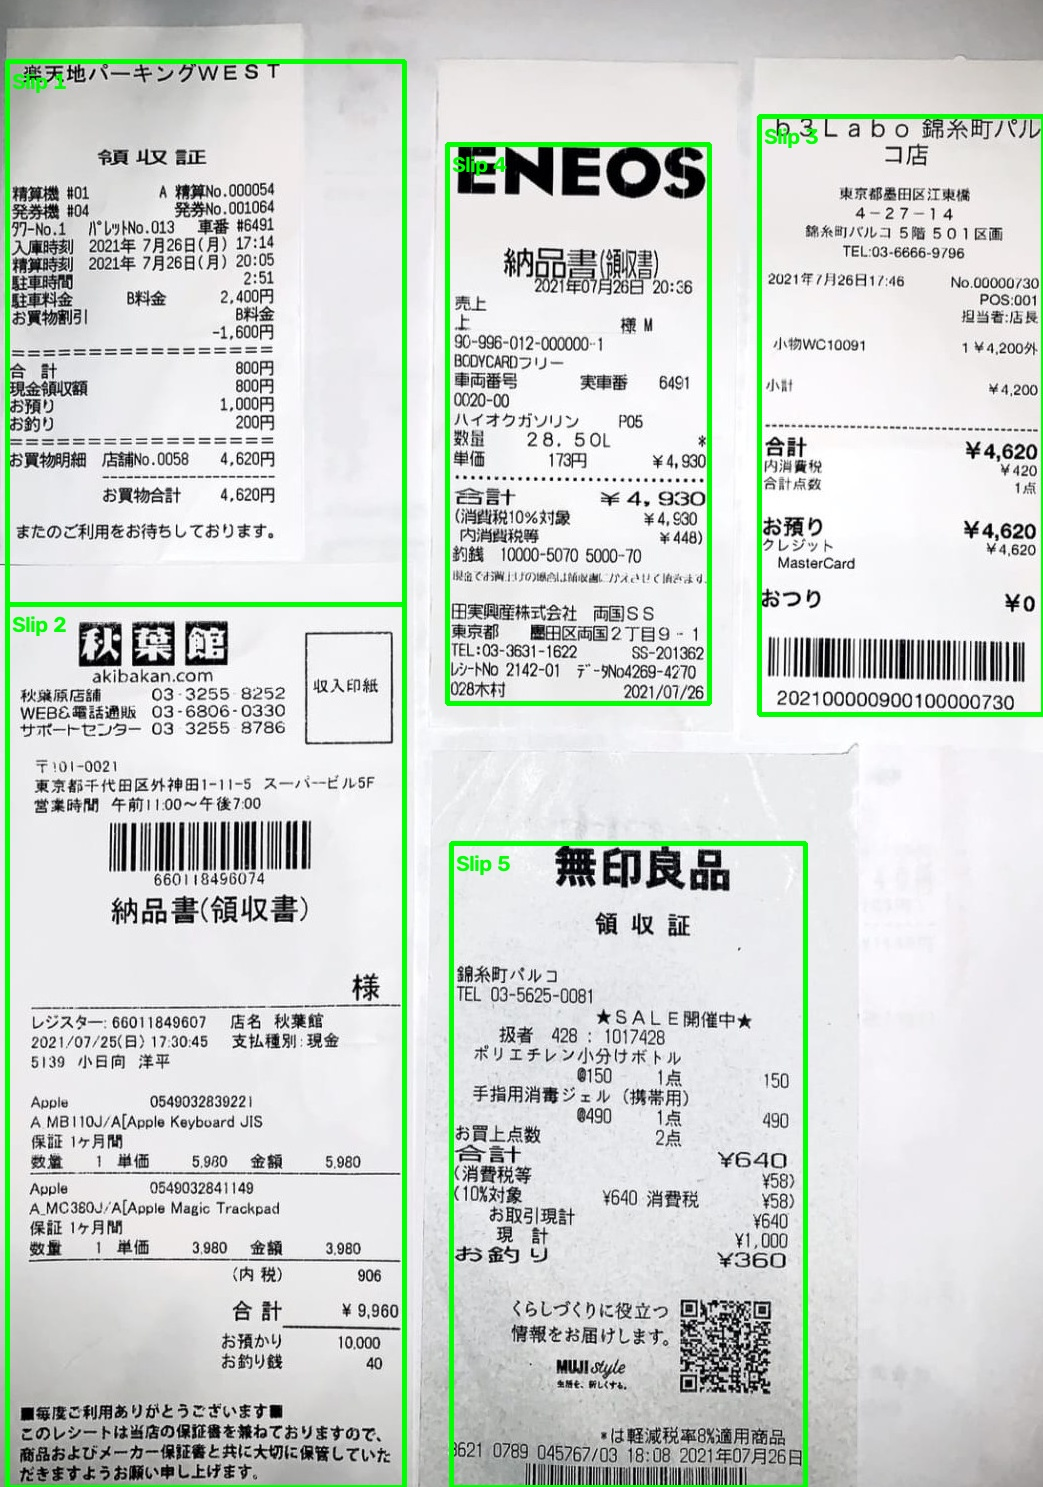

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ====================================================
# QUIZ 2 — Receipt Segmentation (Google Colab)
# 2023-SE-29
# ====================================================

!pip -q install opencv-python-headless numpy

import cv2
import numpy as np
from pathlib import Path
from collections import deque
from google.colab import files
from google.colab.patches import cv2_imshow
import shutil


# ----------------------------------------------------
# 1) Remove scanner/image border
# ----------------------------------------------------
def crop_scanner_frame(image):
    top, bottom, left, right = 22, 33, 26, 16
    height, width = image.shape[:2]

    return image[
        top:height-bottom,
        left:width-right
    ]


# ----------------------------------------------------
# 2) Find all receipt regions using contours
# ----------------------------------------------------
def detect_receipt_boxes(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    smooth_image = cv2.GaussianBlur(gray_image, (9, 9), 0)

    edge_image = cv2.Canny(smooth_image, 30, 150)

    # Connect the vertical receipt structure
    vertical_joiner = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, 120)
    )

    connected_edges = cv2.morphologyEx(
        edge_image,
        cv2.MORPH_CLOSE,
        vertical_joiner
    )

    contour_mask = cv2.dilate(
        connected_edges,
        cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
        iterations=2
    )

    contours, _ = cv2.findContours(
        contour_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = []

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        # Normal receipt
        normal_slip = 250 <= w <= 500 and 500 <= h <= 1100

        # Very tall combined receipt
        mega_slip = 250 <= w <= 500 and h > 1100

        if normal_slip or mega_slip:
            boxes.append((x, y, w, h))

    return sorted(boxes, key=lambda box: (box[1], box[0]))


# ----------------------------------------------------
# 3) Find horizontal gap in a tall combined receipt
# ----------------------------------------------------
def find_horizontal_split(receipt):
    gray_receipt = cv2.cvtColor(receipt, cv2.COLOR_BGR2GRAY)

    # Horizontal changes across the receipt
    horizontal_change = cv2.Sobel(
        gray_receipt,
        cv2.CV_32F,
        0,
        1,
        ksize=3
    )

    horizontal_change = np.abs(horizontal_change)

    # One value for every row
    row_activity = cv2.reduce(
        horizontal_change,
        1,
        cv2.REDUCE_SUM,
        dtype=cv2.CV_32F
    ).flatten()

    height = receipt.shape[0]

    # Avoid top/bottom edges; find the quietest horizontal gap
    start_row = int(height * 0.30)
    end_row = int(height * 0.70)

    split_row = start_row + np.argmin(
        row_activity[start_row:end_row]
    )

    # Accept only a genuinely quiet gap
    if row_activity[split_row] < np.mean(row_activity) * 0.50:
        return split_row

    return None


# ----------------------------------------------------
# 4) Split tall receipt without recursive function
# ----------------------------------------------------
def divide_mega_slip(image, x, y, w, h):
    final_parts = []
    pending_parts = deque([(x, y, w, h)])

    while pending_parts:
        part_x, part_y, part_w, part_h = pending_parts.popleft()

        receipt_part = image[
            part_y:part_y + part_h,
            part_x:part_x + part_w
        ]

        # Only split large combined receipts
        if part_h > 1050:
            gap = find_horizontal_split(receipt_part)

            if gap is not None and gap > 250 and part_h - gap > 250:
                pending_parts.append(
                    (part_x, part_y, part_w, gap)
                )

                pending_parts.append(
                    (part_x, part_y + gap, part_w, part_h - gap)
                )

                continue

        final_parts.append((part_x, part_y, part_w, part_h))

    return final_parts


# ----------------------------------------------------
# 5) Complete pipeline
# ----------------------------------------------------
def run_quiz_2(image_file, output_folder="/content/output_slips"):
    original = cv2.imread(image_file)

    if original is None:
        raise ValueError("Image open nahi hui. Dobara upload karein.")

    prepared_image = crop_scanner_frame(original)
    preview = prepared_image.copy()

    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    receipt_boxes = detect_receipt_boxes(prepared_image)

    slip_number = 1

    for x, y, w, h in receipt_boxes:

        # Split only mega slips; standard slips stay complete
        if h > 1100:
            final_boxes = divide_mega_slip(
                prepared_image, x, y, w, h
            )
        else:
            final_boxes = [(x, y, w, h)]

        for sx, sy, sw, sh in final_boxes:
            cropped_slip = prepared_image[sy:sy+sh, sx:sx+sw]

            file_name = output_path / f"slip_{slip_number}.jpg"
            cv2.imwrite(str(file_name), cropped_slip)

            cv2.rectangle(
                preview,
                (sx, sy),
                (sx + sw, sy + sh),
                (0, 255, 0),
                3
            )

            cv2.putText(
                preview,
                f"Slip {slip_number}",
                (sx + 5, sy + 28),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.75,
                (0, 255, 0),
                2
            )

            print(f"Saved Slip {slip_number}: {sw}x{sh}")
            slip_number += 1

    preview_path = output_path / "segmentation_preview.jpg"
    cv2.imwrite(str(preview_path), preview)

    print(f"\nTotal slips saved: {slip_number - 1}")
    return str(preview_path)


# ----------------------------------------------------
# 6) Upload image, run pipeline, show and download
# ----------------------------------------------------
print("Upload combined receipt image:")
uploaded = files.upload()

if not uploaded:
    raise ValueError("Image upload nahi hui.")

input_image = next(iter(uploaded))

preview_path = run_quiz_2(input_image)

print("\nFinal Preview:")
cv2_imshow(cv2.imread(preview_path))

shutil.make_archive(
    "/content/quiz2_slips",
    "zip",
    "/content/output_slips"
)

files.download("/content/quiz2_slips.zip")